#  Extraction des Caractéristiques d'Engagement Étudiant
    Statut : Prototype de recherche — Ce notebook est un espace d'exploration et de test. Il ne fait pas partie de l'application IA en production et n'a pas vocation à y être intégré tel quel. Son objectif est de valider les indicateurs d'engagement avant toute implémentation réelle.
## Contexte et Objectif

Ce notebook analyse les **logs d'interaction** entre les étudiants et l'assistant pédagogique intelligent pour produire des **indicateurs d'engagement**. Ces indicateurs permettent à l'enseignant de suivre l'engagement et la continuité d'apprentissage.:

| Indicateur | Ce qu'il révèle |
|---|---|
| Nombre de questions par section | Les chapitres les plus difficiles |
| Répétition de questions | Les notions non comprises |
| Tableau de bord par étudiant | Le profil d'engagement individuel |

## Pipeline général

```
Logs JSON  ──►  Nettoyage  ──►  Calcul des indicateurs  ──►  Visualisations  ──►  Dashboard CSV
```

> **Note** : en l'absence temporaire d'une vraie base de logs, on génère un jeu de données synthétique réaliste pour illustrer les calculs.


## 1. Imports et Configuration

On charge toutes les bibliothèques nécessaires en une seule cellule pour faciliter la gestion des dépendances.


In [2]:
#  Bibliothèques standard 
import json
import os
import random
from datetime import datetime, timedelta
from pathlib import Path

#  Calcul numérique & données 
import numpy as np
import pandas as pd

#  Visualisation 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

#  Reproductibilité : fixer les graines aléatoires 
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

#  Style global des graphiques 
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print("Imports réussis.")

Imports réussis.


## 2. Chargement du Cours

Le cours est stocké dans un fichier `cours.json` structuré en chapitres et slides. On extrait la liste de toutes les slides avec leurs métadonnées (id, nom du chapitre, section) pour les utiliser dans la simulation.


In [3]:
COURSE_PATH = Path("../data/2-json/cours.json")

if not COURSE_PATH.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {COURSE_PATH}\n"
        "Vérifiez que le répertoire data/2-json/ contient bien cours.json"
    )

with open(COURSE_PATH, "r", encoding="utf-8") as f:
    course = json.load(f)

# Aplatir toutes les slides de tous les chapitres en une seule liste
slides = []
for chap in course["chapters"]:
    for slide in chap["content"]:
        slides.append({
            "section"   : slide["section"],
            "chap_id"   : chap["chap_id"],
            "chap_name" : chap["chap_name"],
        })

print(f" {len(course['chapters'])} chapitre(s) chargé(s)")
print(f" {len(slides)} slide(s) au total")

# Aperçu de la structure
pd.DataFrame(slides).drop_duplicates(subset="chap_name")[["chap_id", "chap_name"]].reset_index(drop=True)

 2 chapitre(s) chargé(s)
 75 slide(s) au total


,chap_id,chap_name
0,1,Représentation temporelle des signaux
1,2,Systèmes linéaires continus


## 3. Génération des Logs Synthétiques

### Modèle de simulation

Chaque étudiant est simulé avec :
- **4 à 12 sessions** de travail réparties sur 2 mois
- **1 à 6 questions** par session
- Une distribution **non uniforme** des questions (certaines notions sont plus souvent demandées)
- Des **répétitions intentionnelles** (certains étudiants posent plusieurs fois la même question)

### Structure d'un log

```json
{
  "user_id": "etudiant_03",
  "session_id": "etudiant_03_s02",
  "timestamp": "2025-02-10T14:32:00",
  "section": "Transformée de Fourier",
  "chap_name": "Analyse spectrale",
  "chap_id": 2,
  "question": "Qu'est-ce que le spectre d'amplitude ?",
  "session_duration_min": 23.4
}
```


In [4]:
#  Paramètres de simulation 
N_STUDENTS   = 10
START_DATE   = datetime(2025, 1, 15)
STUDENTS     = [f"etudiant_{i:02d}" for i in range(1, N_STUDENTS + 1)]

# Questions de test avec des poids (notions plus ou moins difficiles)
SAMPLE_QUESTIONS = [
    "Qu'est-ce qu'un signal périodique ?",
    "Définition de l'énergie d'un signal",
    "Différence signal analogique et numérique ?",
    "Qu'est-ce que le spectre d'amplitude ?",
    "Qu'est-ce que la convolution ?",
    "Définition de la puissance d'un signal",
]
# Poids : les 3 premières questions sont plus fréquentes (notions fondamentales)
QUESTION_WEIGHTS = [4, 3, 3, 1, 1, 1]

#  Génération des logs 
logs = []
for student in STUDENTS:
    n_sessions = random.randint(4, 12)

    for s in range(n_sessions):
        session_start       = START_DATE + timedelta(days=random.randint(0, 60), hours=random.randint(8, 22))
        session_duration    = max(5.0, random.gauss(25, 10))   # durée min 5 min
        n_questions         = random.randint(1, 6)

        for q_idx in range(n_questions):
            question   = random.choices(SAMPLE_QUESTIONS, weights=QUESTION_WEIGHTS, k=1)[0]
            slide_info = random.choice(slides)
            # Horodatage : questions réparties uniformément sur la session
            ts = session_start + timedelta(minutes=q_idx * session_duration / n_questions)

            logs.append({
                "user_id"             : student,
                "session_id"          : f"{student}_s{s:02d}",
                "timestamp"           : ts.isoformat(),
                "section"             : slide_info["section"],
                "chap_name"           : slide_info["chap_name"],
                "chap_id"             : slide_info["chap_id"],
                "question"            : question,
                "session_duration_min": round(session_duration, 1),
            })

#  Conversion en DataFrame 
df_logs = pd.DataFrame(logs)
df_logs["timestamp"] = pd.to_datetime(df_logs["timestamp"], format="ISO8601")
df_logs["date"]      = df_logs["timestamp"].dt.date
df_logs["week"]      = df_logs["timestamp"].dt.isocalendar().week.astype(int)

print(f" {len(df_logs)} interactions générées")
print(f"   {df_logs['user_id'].nunique()} étudiants  |  "
      f"{df_logs['session_id'].nunique()} sessions  |  "
      f"{df_logs['question'].nunique()} questions uniques")
print()
df_logs.head(3)

 242 interactions générées
   10 étudiants  |  77 sessions  |  6 questions uniques



,user_id,session_id,timestamp,section,chap_name,chap_id,question,session_duration_min,date,week
0,etudiant_01,etudiant_01_s00,2025-01-16 19:00:00.000000,Produit de convolution : Propriétés,Systèmes linéaires continus,2,Qu'est-ce qu'un signal périodique ?,23.9,2025-01-16,3
1,etudiant_01,etudiant_01_s00,2025-01-16 19:03:58.868414,Les systèmes Linéaires Invariants Temporelleme...,Systèmes linéaires continus,2,Qu'est-ce qu'un signal périodique ?,23.9,2025-01-16,3
2,etudiant_01,etudiant_01_s00,2025-01-16 19:07:57.736828,Signaux continus / discrets,Représentation temporelle des signaux,1,Qu'est-ce qu'un signal périodique ?,23.9,2025-01-16,3


## 4. Indicateur 1 — Nombre de Questions par Section

**Interprétation pédagogique** : Une section avec beaucoup de questions indique que les étudiants ont du mal à comprendre par eux-mêmes. L'enseignant peut décider d'y consacrer plus de temps en cours ou d'améliorer le contenu.


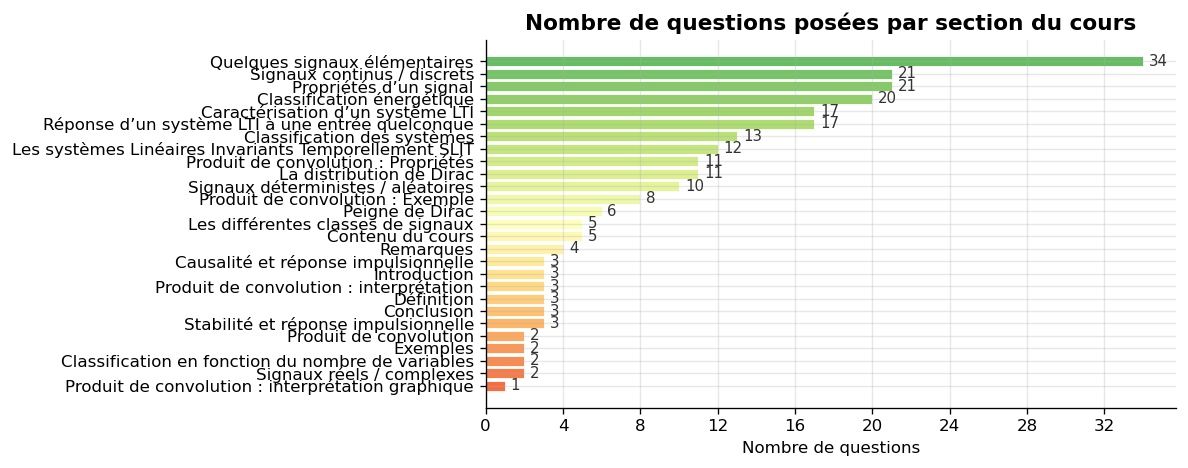

                                              section  nb_questions
                        Quelques signaux élémentaires            34
                          Signaux continus / discrets            21
                               Propriétés d’un signal            21
                           Classification énergétique            20
                     Caractérisation d’un système LTI            17
     Réponse d’un système LTI à une entrée quelconque            17
                          Classification des systèmes            13
Les systèmes Linéaires Invariants Temporellement SLIT            12
                  Produit de convolution : Propriétés            11
                             La distribution de Dirac            11
                   Signaux déterministes / aléatoires            10
                     Produit de convolution : Exemple             8
                                      Peigne de Dirac             6
                   Les différentes classes de si

In [5]:
#  Calcul 
questions_par_section = (
    df_logs.groupby("section", as_index=False)["question"]
    .count()
    .rename(columns={"question": "nb_questions"})
    .sort_values("nb_questions", ascending=False)
    .reset_index(drop=True)
)

#  Visualisation 
fig, ax = plt.subplots(figsize=(10, 4))

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(questions_par_section)))
ax.barh(
    questions_par_section["section"][::-1],
    questions_par_section["nb_questions"][::-1],
    color=colors[::-1],
    edgecolor="white",
    linewidth=0.5,
)

# Annotations : valeur à droite de chaque barre
for i, (_, row) in enumerate(questions_par_section[::-1].iterrows()):
    ax.text(row["nb_questions"] + 0.3, i, str(row["nb_questions"]),
            va="center", fontsize=9, color="#333")

ax.set_title("Nombre de questions posées par section du cours", fontsize=13, fontweight="bold")
ax.set_xlabel("Nombre de questions")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print(questions_par_section.to_string(index=False))

## 5. Indicateur 2 — Répétition de Questions

On distingue deux types de répétitions :

- **Répétition exacte** : l'étudiant pose textuellement la même question → indique un blocage persistant
- **Répétition sémantique** : questions différentes mais proches par le sens → indique une incompréhension plus large d'une notion

### 5a. Répétition Exacte


In [6]:
#  Calcul des répétitions exactes 
repetitions_exactes = (
    df_logs.groupby(["user_id", "question"])["session_id"]
    .count()
    .rename("nb_fois")
    .reset_index()
    .query("nb_fois > 1")                       # garder uniquement les répétitions
    .sort_values("nb_fois", ascending=False)
    .reset_index(drop=True)
)

n_etudiants_concernes = repetitions_exactes["user_id"].nunique()
print(f"  {n_etudiants_concernes} étudiant(s) ont posé au moins une question en double.")
print()

if repetitions_exactes.empty:
    print("Aucune répétition exacte détectée.")
else:
    # Affichage tronqué si trop de lignes
    display_n = min(15, len(repetitions_exactes))
    print(repetitions_exactes.head(display_n).to_string(index=False))
    if len(repetitions_exactes) > display_n:
        print(f"  … et {len(repetitions_exactes) - display_n} lignes supplémentaires.")

  10 étudiant(s) ont posé au moins une question en double.

    user_id                                    question  nb_fois
etudiant_06         Définition de l'énergie d'un signal       15
etudiant_04         Qu'est-ce qu'un signal périodique ?       13
etudiant_10         Qu'est-ce qu'un signal périodique ?       11
etudiant_06         Qu'est-ce qu'un signal périodique ?       10
etudiant_09         Qu'est-ce qu'un signal périodique ?       10
etudiant_10         Définition de l'énergie d'un signal        9
etudiant_06 Différence signal analogique et numérique ?        9
etudiant_09 Différence signal analogique et numérique ?        8
etudiant_03         Qu'est-ce qu'un signal périodique ?        8
etudiant_07 Différence signal analogique et numérique ?        7
etudiant_01         Qu'est-ce qu'un signal périodique ?        7
etudiant_10 Différence signal analogique et numérique ?        6
etudiant_02         Définition de l'énergie d'un signal        6
etudiant_05         Qu'est-ce 

### 5b. Répétition Sémantique (Embeddings + Similarité Cosinus)

**Pourquoi les embeddings ?**  
Un étudiant peut reformuler la même question de plusieurs façons : *"Qu'est-ce que l'énergie d'un signal ?"* et *"Définition de l'énergie d'un signal"* sont semantiquement identiques. La comparaison textuelle exacte ne les détecterait pas.

**Méthode** :
1. Encoder chaque question unique avec un modèle de langue multilingue (`multilingual-e5-base`)
2. Calculer la **matrice de similarité cosinus** entre toutes les paires
3. Regrouper les questions dont la similarité dépasse un seuil `SIM_THRESHOLD`

```
Question A   [0.23, -0.17, ..., 0.88]  
                                               cosine_sim(A, B) = 0.91 > 0.85 → même groupe
Question B   [0.21, -0.19, ..., 0.85]  
```


In [7]:
#  Chargement silencieux du modèle 
import os
os.environ["TQDM_DISABLE"] = "1"   # désactiver les barres de progression tqdm

# Remplacer tqdm notebook (widgets) par tqdm texte simple
import tqdm.auto
from tqdm import tqdm as tqdm_std
tqdm.auto.tqdm = tqdm_std

from sentence_transformers import SentenceTransformer

MODEL_NAME = "intfloat/multilingual-e5-base"
print(f" Chargement du modèle '{MODEL_NAME}' …")
model = SentenceTransformer(MODEL_NAME)
print(f" Modèle chargé : {model.get_sentence_embedding_dimension()} dimensions")

 Chargement du modèle 'intfloat/multilingual-e5-base' …


Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 2479.43it/s]
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Modèle chargé : 768 dimensions


In [8]:
#  Encodage des questions uniques 
# Le préfixe "query: " est recommandé par multilingual-e5 pour les questions
unique_questions = df_logs["question"].unique().tolist()
print(f" {len(unique_questions)} questions uniques à encoder…")

q_embeddings = model.encode(
    [f"query: {q}" for q in unique_questions],
    normalize_embeddings=True,     # normalisation L2 → similarité cosinus = produit scalaire
    show_progress_bar=False,
)

#  Matrice de similarité cosinus 
# shape : (n_questions, n_questions)  — symétrique, diagonale = 1.0
sim_matrix = np.dot(q_embeddings, q_embeddings.T)
print(f" Matrice de similarité : {sim_matrix.shape}")

#  Clustering glouton 
# Algorithme simple : parcourir les questions dans l'ordre, 
# regrouper toutes celles qui dépassent le seuil avec la question courante.
SIM_THRESHOLD = 0.85
groups  = []
visited = set()

for i, q in enumerate(unique_questions):
    if i in visited:
        continue
    # Trouver toutes les questions similaires non encore visitées
    similar_indices = [
        j for j, q2 in enumerate(unique_questions)
        if j != i and j not in visited and sim_matrix[i, j] >= SIM_THRESHOLD
    ]
    group = [q] + [unique_questions[j] for j in similar_indices]
    visited.update([i] + similar_indices)
    groups.append(group)

#  Affichage des résultats 
print(f"\n Résultats (seuil = {SIM_THRESHOLD}) :")
n_clusters = sum(1 for g in groups if len(g) > 1)
print(f"   {n_clusters} groupe(s) de questions sémantiquement similaires trouvé(s)\n")

for k, g in enumerate(groups, start=1):
    if len(g) > 1:
        print(f"   Groupe {k} ({len(g)} questions proches) :")
        for q in g:
            print(f"      - {q}")
    else:
        print(f"   Question isolée : {g[0]}")

 6 questions uniques à encoder…
 Matrice de similarité : (6, 6)

 Résultats (seuil = 0.85) :
   2 groupe(s) de questions sémantiquement similaires trouvé(s)

   Groupe 1 (4 questions proches) :
      - Qu'est-ce qu'un signal périodique ?
      - Différence signal analogique et numérique ?
      - Définition de l'énergie d'un signal
      - Définition de la puissance d'un signal
   Groupe 2 (2 questions proches) :
      - Qu'est-ce que la convolution ?
      - Qu'est-ce que le spectre d'amplitude ?


## 6. Dashboard Synthétique par Étudiant

On agrège tous les indicateurs en un **tableau de bord unique** exploitable par l'enseignant.

| Colonne | Description |
|---|---|
| `nb_questions_total` | Volume total d'interactions |
| `nb_sessions` | Nombre de séances de travail |
| `nb_repetitions` | Questions posées plusieurs fois (signal d'alerte) |
| `taux_repetition` | % de questions répétées |
| `duree_moy_session_min` | Durée moyenne d'une session |
| `chapitre_fav` | Chapitre le plus consulté |


In [9]:
#  Calcul des agrégats 
nb_questions  = df_logs.groupby("user_id")["question"].count().rename("nb_questions_total")
nb_sessions   = df_logs.groupby("user_id")["session_id"].nunique().rename("nb_sessions")
nb_reps       = repetitions_exactes.groupby("user_id")["nb_fois"].sum().rename("nb_repetitions")
duree_moy     = (
    df_logs.groupby(["user_id", "session_id"])["session_duration_min"].first()
    .groupby("user_id").mean()
    .round(1)
    .rename("duree_moy_session_min")
)
chapitre_fav  = (
    df_logs.groupby(["user_id", "chap_name"])["question"].count()
    .reset_index()
    .sort_values("question", ascending=False)
    .groupby("user_id").first()["chap_name"]
    .rename("chapitre_fav")
)

#  Assemblage du dashboard 
dashboard = pd.concat([nb_questions, nb_sessions, nb_reps, duree_moy, chapitre_fav], axis=1)
dashboard["nb_repetitions"]  = dashboard["nb_repetitions"].fillna(0).astype(int)
dashboard["taux_repetition"] = (dashboard["nb_repetitions"] / dashboard["nb_questions_total"] * 100).round(1)

# Réordonner les colonnes
dashboard = dashboard[
    ["nb_questions_total", "nb_sessions", "nb_repetitions",
     "taux_repetition", "duree_moy_session_min", "chapitre_fav"]
].sort_values("nb_questions_total", ascending=False)

print("=" * 60)
print("   TABLEAU DE BORD ENSEIGNANT")
print("=" * 60)
print(dashboard.to_string())

#  Sauvegarde 
OUTPUT_PATH = Path("../data/dashboard_engagement.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
dashboard.to_csv(OUTPUT_PATH)
print(f"\n Dashboard sauvegardé dans {OUTPUT_PATH}")

   TABLEAU DE BORD ENSEIGNANT
             nb_questions_total  nb_sessions  nb_repetitions  taux_repetition  duree_moy_session_min                           chapitre_fav
user_id                                                                                                                                    
etudiant_06                  42           12              42            100.0                   25.1  Représentation temporelle des signaux
etudiant_10                  32            9              32            100.0                   29.8  Représentation temporelle des signaux
etudiant_09                  30            8              29             96.7                   19.0            Systèmes linéaires continus
etudiant_03                  28           12              27             96.4                   29.4  Représentation temporelle des signaux
etudiant_02                  25            9              25            100.0                   28.3  Représentation temporelle de

## 7. Heatmap d'Engagement

Une heatmap **étudiants × chapitres** permet à l'enseignant d'identifier en un coup d'œil quels chapitres posent problème à quels étudiants spécifiquement.


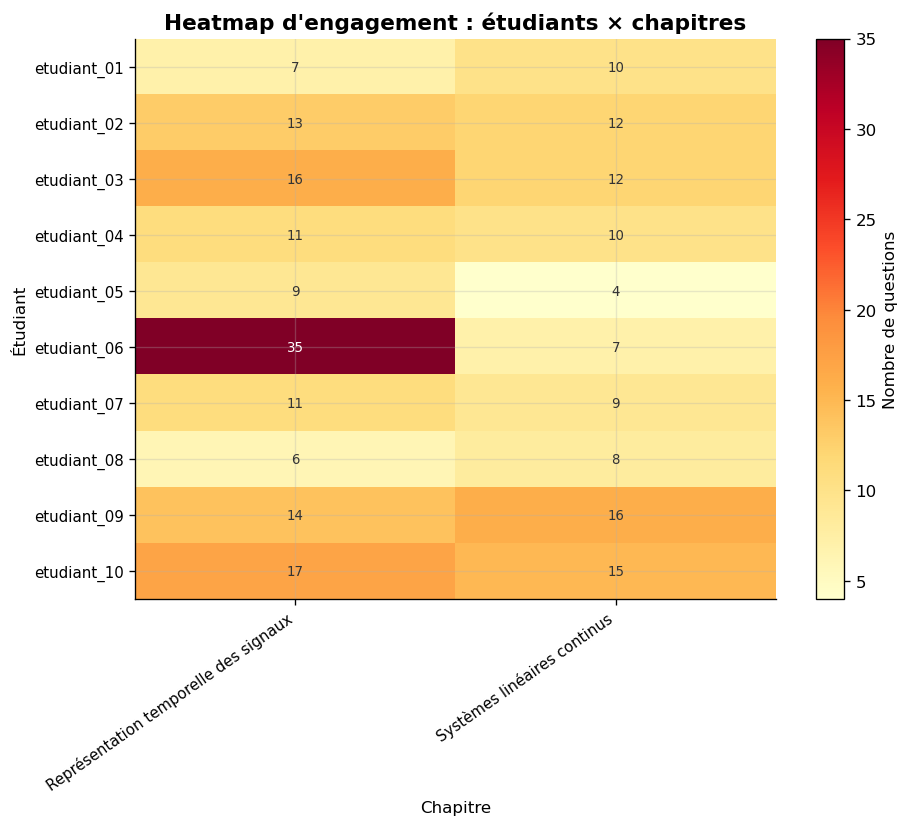

In [10]:
#  Pivot : étudiants × chapitres 
pivot = (
    df_logs.groupby(["user_id", "chap_name"])["question"]
    .count()
    .unstack(fill_value=0)
)

#  Heatmap 
fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 1.4), max(5, len(pivot) * 0.7)))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")

# Axes
ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns, rotation=35, ha="right", fontsize=9)
ax.set_yticklabels(pivot.index, fontsize=9)

# Annotations : valeur dans chaque cellule
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        color = "white" if val > pivot.values.max() * 0.6 else "#333"
        ax.text(j, i, str(val), ha="center", va="center", fontsize=8, color=color)

plt.colorbar(im, ax=ax, label="Nombre de questions")
ax.set_title("Heatmap d'engagement : étudiants × chapitres", fontsize=13, fontweight="bold")
ax.set_xlabel("Chapitre")
ax.set_ylabel("Étudiant")
plt.tight_layout()
plt.show()

## 8. Récapitulatif

Ce notebook calcule **3 catégories d'indicateurs** :

1. **Distribution par section** → identifier les chapitres difficiles
2. **Répétitions exactes & sémantiques** → détecter les blocages individuels
3. **Dashboard synthétique + heatmap** → vue d'ensemble pour l'enseignant